# Tc Extraction from R(T) Plots
#
# Notebook for developing a Tc (critical temperature) extractor.
#
# **The challenge**: VLMs are bad at extracting the sharp superconducting transition
# in R(T) plots — the near-vertical drop from normal-state resistance to zero
# happens over a very narrow temperature range (~2-5 K) while the full plot spans
# 0-300 K. The VLM tends to "smooth over" it.
#
# **Strategy**: Two complementary approaches, compared side-by-side:
# - **Approach A (Direct VLM):** Ask Claude to directly identify Tc from the plot
#   (no coordinate extraction — just "what temperature does the transition happen?")
# - **Approach B (Extract + Compute):** Extract data points with a specialized prompt
#   that emphasizes the transition region, then compute Tc numerically

## 1. Load and display the image

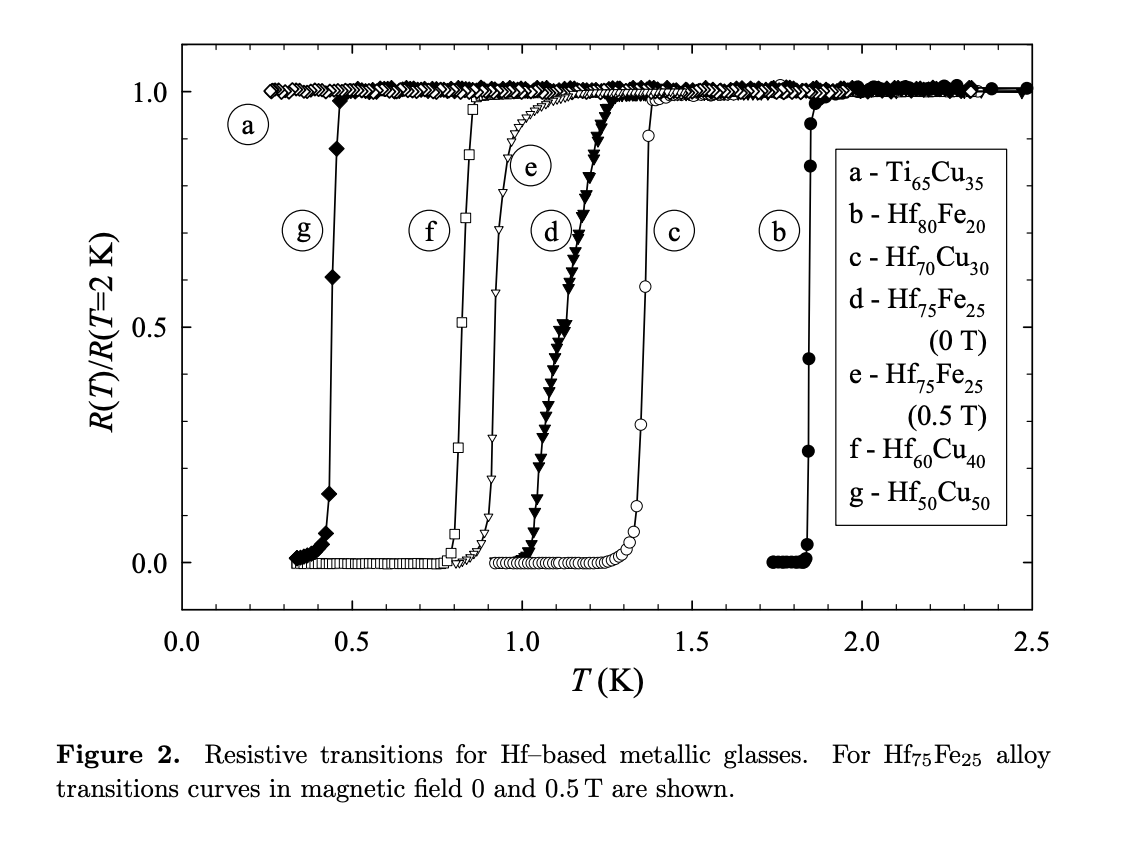

In [33]:
import base64
import os

import numpy as np
from IPython.display import Image, display

from llm_synthesis.models.figure import FigureInfo, FigureInfoWithPaper


def load_image_as_figure(img_path: str) -> FigureInfoWithPaper:
    """Load an image file and wrap it as FigureInfoWithPaper."""
    ext = os.path.splitext(img_path)[1].lower()
    if ext not in [".png", ".jpeg", ".jpg"]:
        raise ValueError(f"Unsupported image format: {ext}")

    with open(img_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")

    return FigureInfoWithPaper(
        base64_data=encoded,
        alt_text="",
        position=0,
        context_before="",
        context_after="",
        figure_reference="",
        figure_class="Graph plots",
        quantitative=True,
        paper_text="",
        si_text="",
    )


# --- Set your image path here ---
IMG_PATH = "/Users/valeriegentzke/Desktop/try2.png"



figure = load_image_as_figure(IMG_PATH)
display(Image(base64.b64decode(base64.b64encode(open(IMG_PATH, "rb").read()))))

## 2. Approach A — Ask Claude directly for Tc

Instead of extracting all data points and computing Tc numerically,
just ask the VLM: "where is the transition?" This sidesteps the extraction
accuracy problem entirely.

In [34]:
from llm_synthesis.services.llm_api.claude import ClaudeAPIClient

DIRECT_TC_PROMPT = """
You are analyzing a Resistance (or Resistivity) vs Temperature plot from a
superconductivity paper. Your task is to determine the critical temperature 
Tc for each series using the standard geometric construction.

STEP 0 — EXAMINE THE FIGURE:
a) Check if the figure contains an INSET or ZOOMED-IN panel that magnifies 
   the transition region. Insets typically show a smaller temperature range 
   (e.g., 30-40 K instead of 0-300 K) and are embedded within the main plot.
b) If an inset exists, use it PREFERENTIALLY for Tc determination — it has 
   much better spatial resolution in the transition region.
c) Read ALL numbered tick marks on BOTH the main plot and the inset (if present).
   List them separately.

STEP 1 — IDENTIFY SERIES:
List every distinct curve (by legend label, color, marker).

STEP 2 — READ RESISTANCE VALUES AT LOWEST AND HIGHEST TEMPERATURE:
For EACH series, read two values:
  a) R_at_lowest_T: the resistance/resistivity value at the LOWEST 
     temperature shown in the plot. Look at the leftmost data point of 
     this series — what y-value does it have?
  b) R_at_highest_T: the resistance/resistivity at the HIGHEST temperature 
     (rightmost data point, i.e., normal-state value).

Report both values for every series. This is critical for determining 
which materials are superconducting.

STEP 3 — CONFIRM SUPERCONDUCTIVITY:
A series is superconducting ONLY if R_at_lowest_T is approximately zero.
  - If R_at_lowest_T is approximately 0 -> SUPERCONDUCTING
  - If R_at_lowest_T is clearly above zero (e.g., 0.1, 0.3, 1.0) -> 
    NOT superconducting, even if the curve has sharp drops or kinks.

For non-superconducting series, report:
  superconducting: NO
  reason: <e.g., "R_at_lowest_T = 0.3, clearly above zero">

STEP 4 — GEOMETRIC Tc CONSTRUCTION (only for confirmed superconductors):
Use the INSET if available (better resolution), otherwise use the main plot.

For each superconducting series:

  a) NORMAL-STATE LEVEL: Read R_normal from the plateau above the transition.

  b) FIND T_onset: Moving left from the high-T plateau, T_onset is where
     resistance FIRST drops below R_normal. This is the HIGHEST temperature
     in the transition.

  c) FIND T_zero: Moving right from low T along R = 0, T_zero is the LAST
     point still at R = 0 before resistance starts rising. T_zero < T_onset.

  d) Tc_mid = (T_onset + T_zero) / 2

  e) Delta_Tc = T_onset - T_zero

STEP 5 — RELATIVE ORDERING OF TRANSITIONS:
Even when transitions appear close together on the plot, they are almost 
never at EXACTLY the same temperature. Look carefully:

  a) For each PAIR of superconducting series, compare which one starts 
     dropping FIRST (at higher T). Look at the actual data points/markers — 
     which series still has high resistance when the other has already 
     started dropping?
  
  b) If series A starts dropping at a higher T than series B, then 
     T_onset(A) > T_onset(B). Even if the difference is small (1-3 K), 
     report it — do NOT round both to the same value.
  
  c) Similarly for T_zero: which series reaches zero resistance at a higher T?

  d) NEVER report identical T_onset values for different series unless you 
     are absolutely certain they are the same after careful comparison.

Output format:

inset_detected: <yes/no>
inset_axes: <tick marks of inset if present, otherwise "N/A">
main_x_axis_ticks: <list>
main_y_axis_ticks: <list>

Series: <name>
R_at_lowest_T: <value and unit>
R_at_highest_T: <value and unit>
superconducting: <YES/NO>
[If NO:]
reason: <why not superconducting>
[If YES:]
R_normal: <value and unit>
T_onset: <value> K
T_zero: <value> K
Tc_mid: <value> K
Delta_Tc: <value> K
source: <"inset" or "main plot">

relative_ordering: <which series transitions first (highest T_onset), 
second, etc. — and by approximately how many K do they differ?>

Do not output any other text.
"""

client = ClaudeAPIClient("claude-sonnet-4-20250514")

response_direct = client.vision_model_api_call(
    figure_base64=figure.base64_data,
    prompt=DIRECT_TC_PROMPT,
    max_tokens=2048,
    temperature=0.0,
)

print("=== Approach A: Direct VLM Tc extraction ===")
print(response_direct)
print(f"Cost: \${client.get_cost():.4f}")

=== Approach A: Direct VLM Tc extraction ===
inset_detected: no
inset_axes: N/A
main_x_axis_ticks: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
main_y_axis_ticks: [0.0, 0.5, 1.0]

Series: a - Ti₆₅Cu₃₅
R_at_lowest_T: 1.0
R_at_highest_T: 1.0
superconducting: NO
reason: R_at_lowest_T = 1.0, clearly above zero

Series: b - Hf₈₀Fe₂₀
R_at_lowest_T: 0.0
R_at_highest_T: 1.0
superconducting: YES
R_normal: 1.0
T_onset: 2.1 K
T_zero: 1.9 K
Tc_mid: 2.0 K
Delta_Tc: 0.2 K
source: main plot

Series: c - Hf₇₀Cu₃₀
R_at_lowest_T: 0.0
R_at_highest_T: 1.0
superconducting: YES
R_normal: 1.0
T_onset: 1.6 K
T_zero: 1.4 K
Tc_mid: 1.5 K
Delta_Tc: 0.2 K
source: main plot

Series: d - Hf₇₅Fe₂₅ (0 T)
R_at_lowest_T: 0.0
R_at_highest_T: 1.0
superconducting: YES
R_normal: 1.0
T_onset: 1.3 K
T_zero: 1.1 K
Tc_mid: 1.2 K
Delta_Tc: 0.2 K
source: main plot

Series: e - Hf₇₅Fe₂₅ (0.5 T)
R_at_lowest_T: 0.0
R_at_highest_T: 1.0
superconducting: YES
R_normal: 1.0
T_onset: 1.1 K
T_zero: 0.9 K
Tc_mid: 1.0 K
Delta_Tc: 0.2 K
source: main plot


## 3. Approach B — Extract all data points, then compute Tc numerically

Extract the full R(T) curve for each series, then find Tc as the 
inflection point (maximum |dR/dT|) in the transition region.

This is the "data extraction" approach — instead of asking Claude 
directly for Tc, we extract coordinates and compute it ourselves.


In [35]:
import re
from llm_synthesis.services.llm_api.claude import ClaudeAPIClient

# ── Approach B: Extract ALL data points from the R(T) plot ──

EXTRACT_RT_PROMPT = """
You are extracting data points from a Resistance (or Resistivity) vs 
Temperature plot. Extract the (T, R) coordinates of EVERY visible data 
point for each series.

STEP 0 — EXAMINE THE FIGURE:
a) Check for an INSET or ZOOMED-IN panel. If present, note it but extract 
   from the MAIN plot (which shows the full temperature range).
b) Read ALL numbered tick marks on the x-axis and y-axis.

STEP 1 — AXIS CALIBRATION (CRITICAL):
1. List every numbered tick mark on both axes.
2. For each data point, identify the TWO nearest tick marks on each axis 
   and interpolate the position between them.

STEP 2 — IDENTIFY SERIES:
List every distinct curve (by legend label, color, marker style).

STEP 3 — EXTRACT DATA POINTS:
For EACH series, extract ALL visible data points as (T, R) pairs.

CRITICAL — SUPERCONDUCTING TRANSITIONS:
Some series may show a superconducting transition where resistance drops 
sharply from a normal-state value to ZERO over a very narrow temperature 
range. In the transition region:
  - Data points may be stacked nearly VERTICALLY (very similar T values 
    but very different R values)
  - There may be 3-8 data points clustered at nearly the same T
  - Extract EACH of these points individually — they are the most 
    important points in the entire plot
  - Do NOT skip or merge these closely-spaced points
  - Do NOT smooth over the transition by spreading points across a wider 
    T range than they actually occupy

For each series, extract points from LOW T to HIGH T, including:
  - All points where R ≈ 0 (superconducting state)
  - All points in the transition (the near-vertical cluster)
  - All points in the normal state above the transition
  - Points at the highest temperatures shown

Output format (one line per series):

Series_Name_1: [[T1, R1], [T2, R2], ...]
Series_Name_2: [[T1, R1], [T2, R2], ...]
title:
x_axis_label:
x_axis_unit:
y_left_axis_label:
y_left_axis_unit:

Do not output any other text, just the data in the format above.
"""

client = ClaudeAPIClient("claude-sonnet-4-20250514")

response_extract = client.vision_model_api_call(
    figure_base64=figure.base64_data,
    prompt=EXTRACT_RT_PROMPT,
    max_tokens=8192,
    temperature=0.0,
)

print("=== Approach B: Full data extraction ===")
print(f"Cost: ${client.get_cost():.4f}")
print(f"\nRaw response (first 3000 chars):")
print(response_extract[:3000])

=== Approach B: Full data extraction ===
Cost: $0.0323

Raw response (first 3000 chars):
Series_a_Ti65Cu35: [[0.1, 1.0], [0.2, 1.0], [0.3, 1.0], [0.4, 1.0], [0.5, 1.0], [0.6, 1.0], [0.7, 1.0], [0.8, 1.0], [0.9, 1.0], [1.0, 1.0], [1.1, 1.0], [1.2, 1.0], [1.3, 1.0], [1.4, 1.0], [1.5, 1.0], [1.6, 1.0], [1.7, 1.0], [1.8, 1.0], [1.9, 1.0], [2.0, 1.0], [2.1, 1.0], [2.2, 1.0], [2.3, 1.0], [2.4, 1.0]]

Series_b_Hf80Fe20: [[1.8, 0.0], [1.85, 0.15], [1.9, 0.4], [1.95, 0.7], [2.0, 0.9], [2.05, 0.95], [2.1, 1.0], [2.15, 1.0], [2.2, 1.0], [2.25, 1.0], [2.3, 1.0], [2.35, 1.0], [2.4, 1.0]]

Series_c_Hf70Cu30: [[1.4, 0.0], [1.42, 0.05], [1.44, 0.15], [1.46, 0.3], [1.48, 0.5], [1.5, 0.7], [1.52, 0.85], [1.54, 0.95], [1.56, 1.0], [1.58, 1.0], [1.6, 1.0], [1.7, 1.0], [1.8, 1.0], [1.9, 1.0], [2.0, 1.0], [2.1, 1.0], [2.2, 1.0], [2.3, 1.0], [2.4, 1.0]]

Series_d_Hf75Fe25_0T: [[1.0, 0.0], [1.02, 0.05], [1.04, 0.15], [1.06, 0.3], [1.08, 0.5], [1.1, 0.7], [1.12, 0.85], [1.14, 0.95], [1.16, 1.0], [1.18, 1.0], [

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from llm_synthesis.transformers.plot_extraction.claude_extraction.plot_data_extraction import (
    ClaudeLinePlotDataExtractor,
)

# Parse the extraction response
_temp_extractor = ClaudeLinePlotDataExtractor.__new__(ClaudeLinePlotDataExtractor)
extracted = _temp_extractor._parse_into_pydantic(response_extract)

print("Extracted series:")
for name, coords in extracted.name_to_coordinates.items():
    coords_arr = np.array(coords)
    print(f"  {name}: {len(coords)} points")
    print(f"    T range: [{coords_arr[:,0].min():.2f}, {coords_arr[:,0].max():.2f}]")
    print(f"    R range: [{coords_arr[:,1].min():.3f}, {coords_arr[:,1].max():.3f}]")
    
    # Check if transition is captured (steep segments)
    if len(coords_arr) > 3:
        t_sorted = coords_arr[coords_arr[:,0].argsort()]
        dt = np.diff(t_sorted[:,0])
        dr = np.abs(np.diff(t_sorted[:,1]))
        # Big R jumps at small T steps = transition
        steep = (dt < 3) & (dr > 0.5 * coords_arr[:,1].max())
        if steep.any():
            print(f"    ✓ Found {steep.sum()} steep segments (transition captured)")
        else:
            # Check if R reaches zero
            if coords_arr[:,1].min() < 0.02 * coords_arr[:,1].max():
                print(f"    ~ R reaches zero but no steep segment detected")
            else:
                print(f"    ✗ R does not reach zero — likely not superconducting")

Extracted series:
  Series_a_Ti65Cu35: 24 points
    T range: [0.10, 2.40]
    R range: [1.000, 1.000]
    ✗ R does not reach zero — likely not superconducting
  Series_b_Hf80Fe20: 13 points
    T range: [1.80, 2.40]
    R range: [0.000, 1.000]
    ~ R reaches zero but no steep segment detected
  Series_c_Hf70Cu30: 19 points
    T range: [1.40, 2.40]
    R range: [0.000, 1.000]
    ~ R reaches zero but no steep segment detected
  Series_d_Hf75Fe25_0T: 23 points
    T range: [1.00, 2.40]
    R range: [0.000, 1.000]
    ~ R reaches zero but no steep segment detected
  Series_e_Hf75Fe25_0.5T: 25 points
    T range: [0.80, 2.40]
    R range: [0.000, 1.000]
    ~ R reaches zero but no steep segment detected
  Series_f_Hf60Cu40: 28 points
    T range: [0.50, 2.40]
    R range: [0.000, 1.000]
    ~ R reaches zero but no steep segment detected
  Series_g_Hf50Cu50: 31 points
    T range: [0.20, 2.40]
    R range: [0.000, 1.000]
    ~ R reaches zero but no steep segment detected


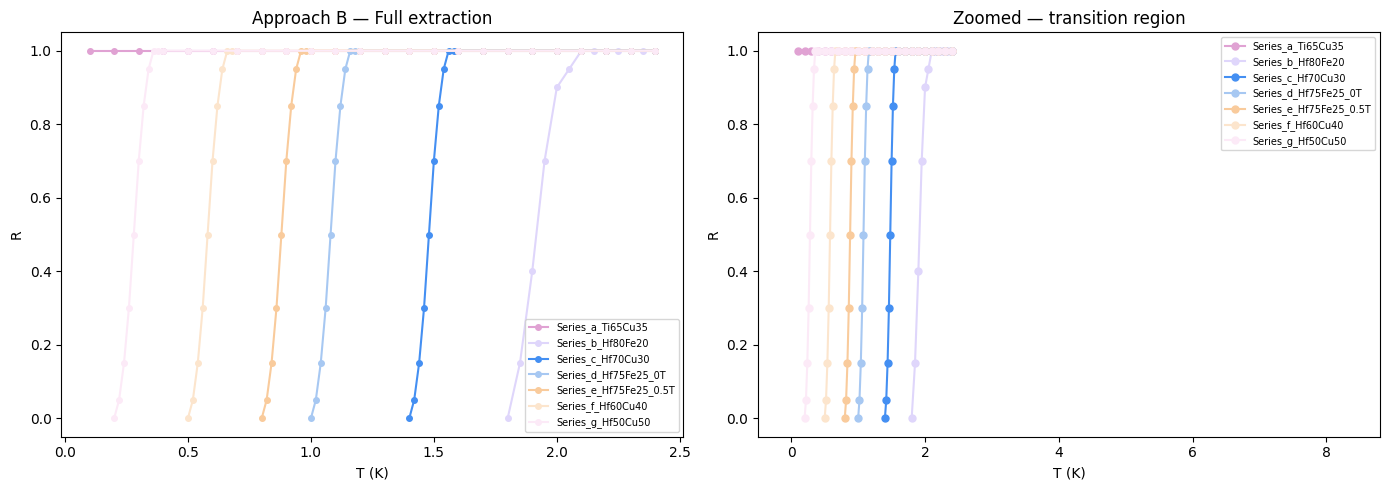

In [37]:
# Visualize extracted data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, coords in extracted.name_to_coordinates.items():
    coords_arr = np.array(coords)
    order = np.argsort(coords_arr[:, 0])
    ax.plot(coords_arr[order, 0], coords_arr[order, 1], "o-", label=name, markersize=4)
ax.set_xlabel("T (K)")
ax.set_ylabel("R")
ax.set_title("Approach B — Full extraction")
ax.legend(fontsize=7)

# Right: zoom into low-T region where transitions happen
ax2 = axes[1]
t_max_zoom = 0
for name, coords in extracted.name_to_coordinates.items():
    coords_arr = np.array(coords)
    order = np.argsort(coords_arr[:, 0])
    ax2.plot(coords_arr[order, 0], coords_arr[order, 1], "o-", label=name, markersize=5)
    # Find where transition might be (where R first drops to near zero)
    if coords_arr[:,1].min() < 0.02 * coords_arr[:,1].max():
        # Find T where R is ~50% of max
        r_mid = 0.5 * coords_arr[:,1].max()
        idx_mid = np.argmin(np.abs(coords_arr[order,1] - r_mid))
        t_trans = coords_arr[order, 0][idx_mid]
        t_max_zoom = max(t_max_zoom, t_trans * 2)

if t_max_zoom > 0:
    ax2.set_xlim(-0.5, t_max_zoom + 5)
ax2.set_xlabel("T (K)")
ax2.set_ylabel("R")
ax2.set_title("Zoomed — transition region")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4. Compute Tc numerically from extracted data


In [38]:
from scipy.interpolate import UnivariateSpline


def find_tc_inflection(temperatures, resistances, smooth_factor=None):
    """
    Find Tc as the inflection point of the R(T) superconducting transition.
    Returns None if the series does not appear to be superconducting.
    """
    t = np.array(temperatures, dtype=float)
    r = np.array(resistances, dtype=float)

    order = np.argsort(t)
    t, r = t[order], r[order]

    r_max = r.max()
    r_min = r.min()
    r_range = r_max - r_min
    
    # Check if this series is superconducting (R drops to near zero)
    if r_min > 0.05 * r_max:
        return None  # R doesn't reach zero — not superconducting

    # Find the transition region
    threshold_low = r_min + 0.05 * r_range
    threshold_high = r_min + 0.95 * r_range

    above_low = np.where(r > threshold_low)[0]
    below_high = np.where(r < threshold_high)[0]

    if len(above_low) == 0 or len(below_high) == 0:
        t_transition_min = t.min()
        t_transition_max = t.max()
    else:
        idx_start = max(0, above_low[0] - 2)
        idx_end = min(len(t) - 1, below_high[-1] + 2)
        t_transition_min = t[idx_start]
        t_transition_max = t[idx_end]

        if t_transition_max - t_transition_min > 0.5 * (t.max() - t.min()):
            t_transition_max = t.min() + 0.4 * (t.max() - t.min())
            t_transition_min = t.min()

    spline = UnivariateSpline(t, r, s=smooth_factor)
    t_fine = np.linspace(t.min(), t.max(), 1000)
    r_fine = spline(t_fine)
    dr_dt = spline.derivative()(t_fine)

    transition_mask = (t_fine >= t_transition_min) & (t_fine <= t_transition_max)

    if transition_mask.any():
        dr_dt_transition = np.abs(dr_dt[transition_mask])
        t_fine_transition = t_fine[transition_mask]
        idx_local = np.argmax(dr_dt_transition)
        tc = t_fine_transition[idx_local]
        rc = float(spline(tc))
    else:
        idx = np.argmax(np.abs(dr_dt))
        tc = t_fine[idx]
        rc = float(r_fine[idx])

    return {
        "tc": float(tc),
        "rc": float(rc),
        "t_fine": t_fine,
        "r_fine": r_fine,
        "dr_dt": dr_dt,
        "transition_region": (float(t_transition_min), float(t_transition_max)),
    }


# Compute Tc for each extracted series
numerical_tc = {}
for name, coords in extracted.name_to_coordinates.items():
    coords_arr = np.array(coords)
    if len(coords_arr) < 4:
        print(f"  {name}: too few points ({len(coords_arr)}), skipping")
        continue
    result = find_tc_inflection(coords_arr[:, 0], coords_arr[:, 1])
    if result is None:
        print(f"  ✗ {name}: NOT superconducting (R doesn't reach zero)")
    else:
        numerical_tc[name] = result
        tr = result["transition_region"]
        print(f"  ✓ {name}: Tc = {result['tc']:.2f} K (transition: {tr[0]:.1f}-{tr[1]:.1f} K)")

  ✗ Series_a_Ti65Cu35: NOT superconducting (R doesn't reach zero)
  ✓ Series_b_Hf80Fe20: Tc = 1.80 K (transition: 1.8-2.0 K)
  ✓ Series_c_Hf70Cu30: Tc = 1.40 K (transition: 1.4-1.6 K)
  ✓ Series_d_Hf75Fe25_0T: Tc = 1.00 K (transition: 1.0-1.2 K)
  ✓ Series_e_Hf75Fe25_0.5T: Tc = 0.80 K (transition: 0.8-1.0 K)
  ✓ Series_f_Hf60Cu40: Tc = 0.50 K (transition: 0.5-0.7 K)
  ✓ Series_g_Hf50Cu50: Tc = 0.20 K (transition: 0.2-0.4 K)


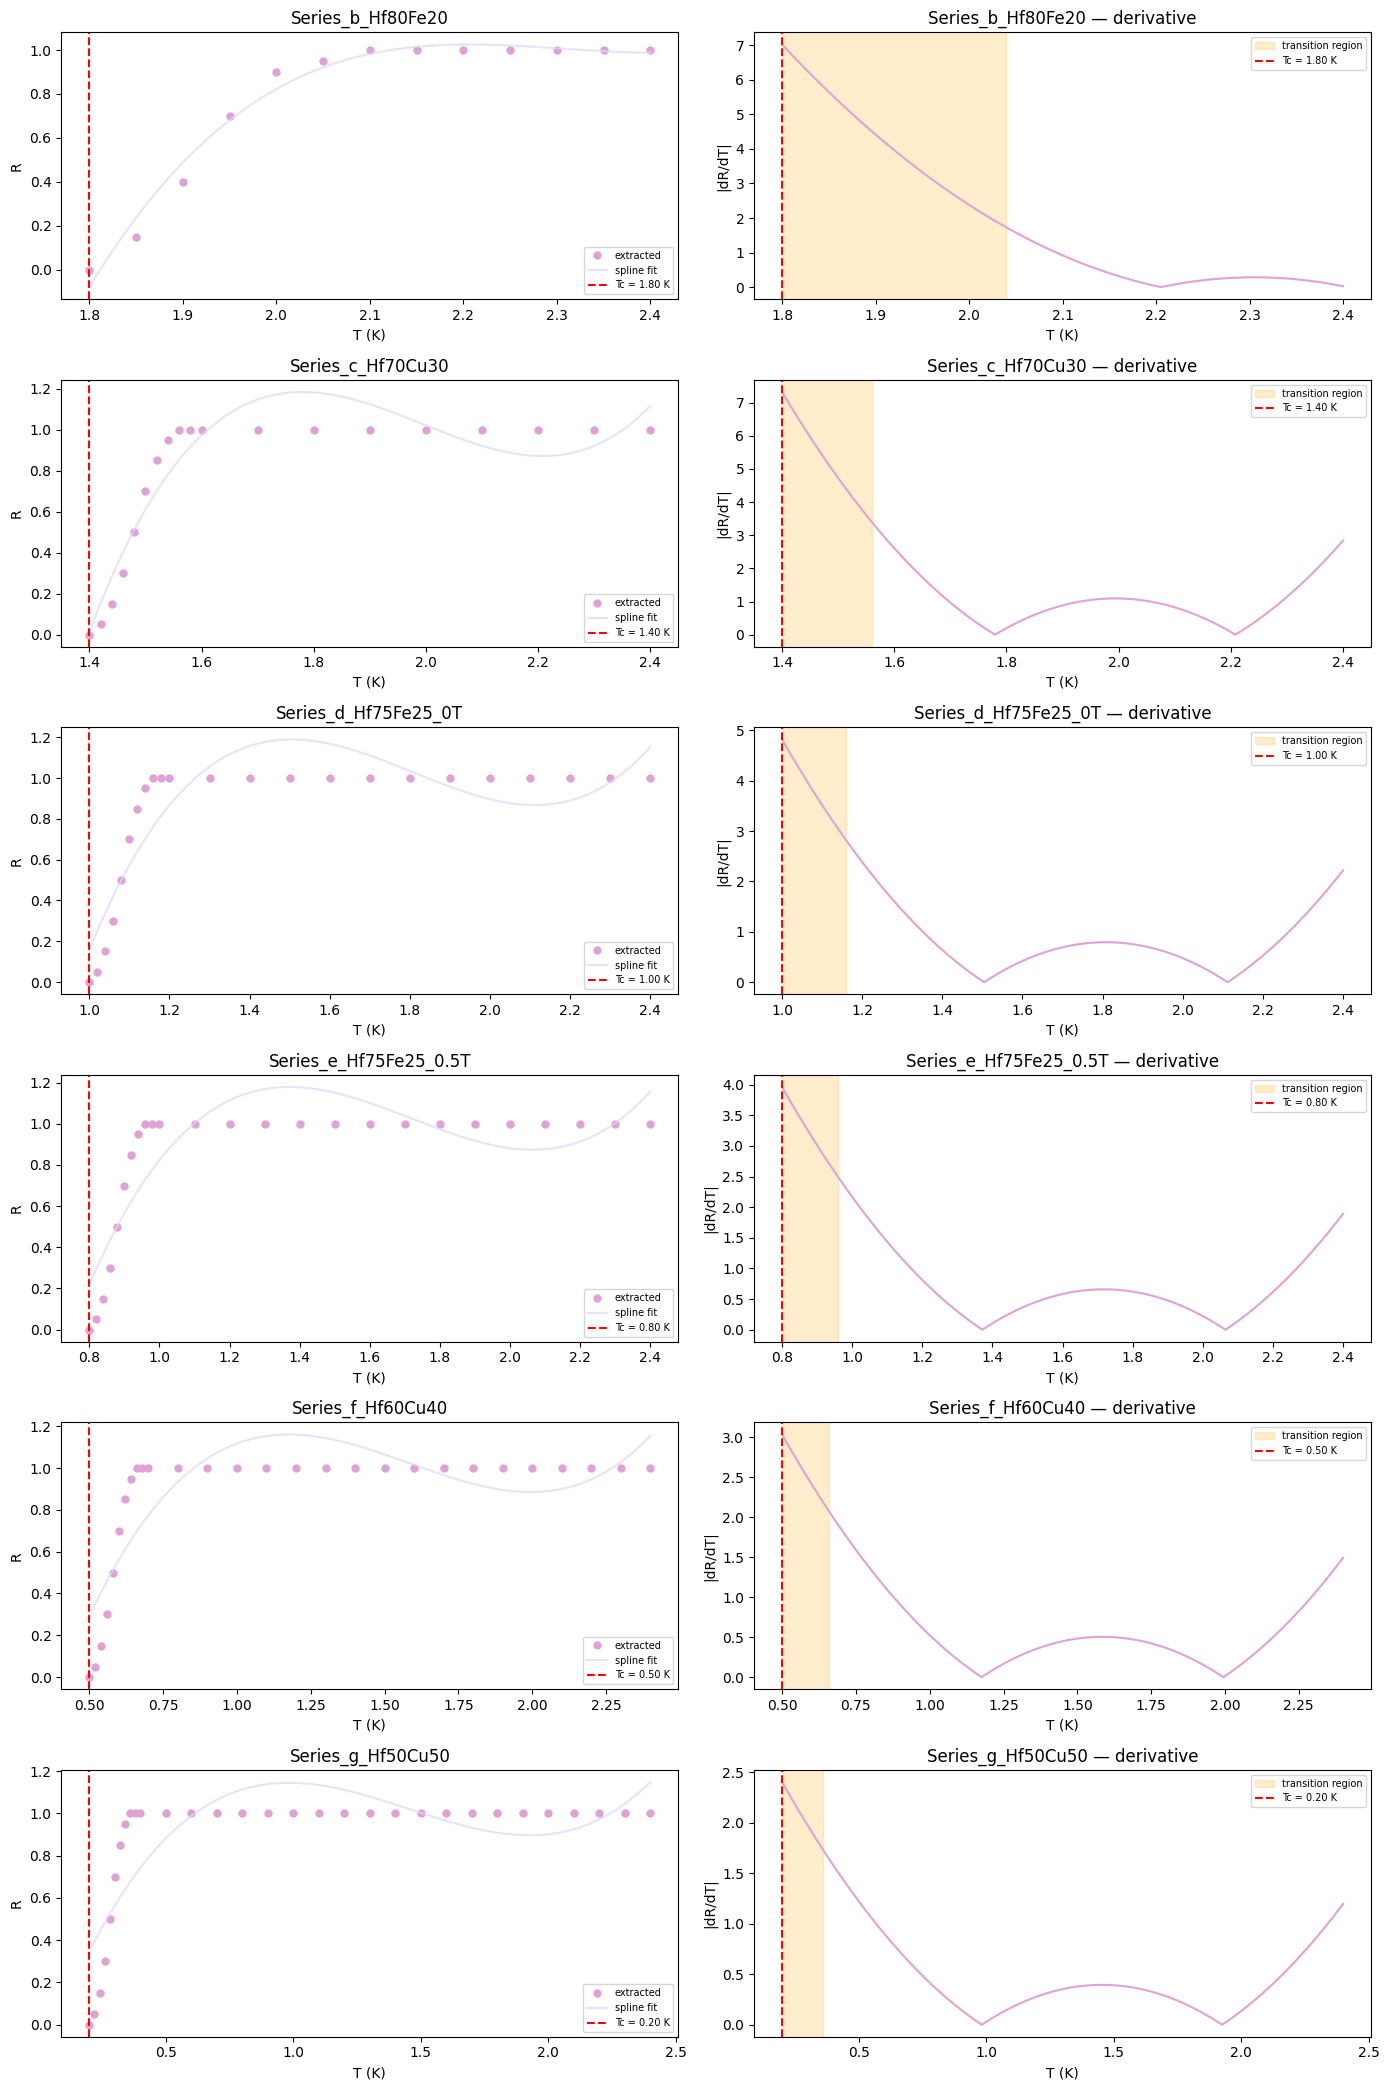

In [39]:
# Visualize the derivative dR/dT for each superconducting series
if not numerical_tc:
    print("No superconducting series found in extraction")
else:
    n_sc = len(numerical_tc)
    fig, axes = plt.subplots(n_sc, 2, figsize=(14, 3.5 * n_sc), squeeze=False)
    
    for i, (name, res) in enumerate(numerical_tc.items()):
        # Left: R(T) with spline fit and Tc marker
        ax = axes[i, 0]
        coords_arr = np.array(extracted.name_to_coordinates[name])
        ax.plot(coords_arr[:, 0], coords_arr[:, 1], "o", markersize=5, label="extracted")
        ax.plot(res["t_fine"], res["r_fine"], "-", alpha=0.7, label="spline fit")
        ax.axvline(res["tc"], color="red", linestyle="--", label=f"Tc = {res['tc']:.2f} K")
        ax.set_xlabel("T (K)")
        ax.set_ylabel("R")
        ax.set_title(f"{name}")
        ax.legend(fontsize=7)
        
        # Right: |dR/dT| with transition region highlighted
        ax2 = axes[i, 1]
        ax2.plot(res["t_fine"], np.abs(res["dr_dt"]), "-")
        tr = res["transition_region"]
        ax2.axvspan(tr[0], tr[1], alpha=0.2, color="orange", label="transition region")
        ax2.axvline(res["tc"], color="red", linestyle="--", label=f"Tc = {res['tc']:.2f} K")
        ax2.set_xlabel("T (K)")
        ax2.set_ylabel("|dR/dT|")
        ax2.set_title(f"{name} — derivative")
        ax2.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()

## 5. Compare Approach A vs Approach B


In [40]:
# ── Parse the direct Tc response from Approach A (cell 4) ──
def parse_direct_tc_response(response_text):
    """Parse the direct Tc prompt response with superconducting YES/NO check."""
    results = {}
    current = None
    for line in response_text.strip().split("\n"):
        line = line.strip()
        if line.startswith("Series:"):
            current = line.split(":", 1)[1].strip()
            results[current] = {}
        elif current and ":" in line:
            key, val = line.split(":", 1)
            key = key.strip().lower().replace(" ", "_")
            val = val.strip()
            if key == "superconducting":
                results[current][key] = val.upper().startswith("YES")
            elif key in ("reason",):
                results[current][key] = val
            else:
                match = re.search(r"([\d.]+)", val)
                if match:
                    results[current][key] = float(match.group(1))
                elif "no transition" in val.lower() or "n/a" in val.lower():
                    results[current][key] = None
                else:
                    results[current][key] = val
    return results

direct_tc_info = parse_direct_tc_response(response_direct)

# ── Full comparison ──
print("=" * 80)
print("COMPARISON: Approach A (Direct VLM) vs Approach B (Extract + Compute)")
print("=" * 80)

# Approach A
print("\n── Approach A: Direct VLM Tc ──")
for series, vals in direct_tc_info.items():
    is_sc = vals.get("superconducting", True)
    if is_sc:
        tc_mid = vals.get("tc_mid")
        t_onset = vals.get("t_onset")
        t_zero = vals.get("t_zero")
        print(f"  ✓ {series}: T_onset={t_onset} K, Tc_mid={tc_mid} K, T_zero={t_zero} K")
    else:
        reason = vals.get("reason", "not superconducting")
        print(f"  ✗ {series}: {reason}")

# Approach B
print("\n── Approach B: Numerical Tc from extracted data ──")
for name, coords in extracted.name_to_coordinates.items():
    if name in numerical_tc:
        res = numerical_tc[name]
        print(f"  ✓ {name}: Tc = {res['tc']:.2f} K")
    else:
        print(f"  ✗ {name}: not superconducting (R doesn't reach zero)")

# Summary table
print("\n" + "=" * 80)
print(f"{'Series':<35} {'A: Tc_mid':>10} {'B: Tc':>10}")
print("-" * 58)

all_names = set()
all_names.update(direct_tc_info.keys())
all_names.update(extracted.name_to_coordinates.keys())

for name in sorted(all_names):
    # Approach A
    a_vals = direct_tc_info.get(name, {})
    a_sc = a_vals.get("superconducting", None)
    a_tc = a_vals.get("tc_mid") if a_sc in (True, None) else None
    a_str = f"{a_tc:.1f} K" if a_tc else ("✗" if a_sc == False else "-")
    
    # Approach B
    b_res = numerical_tc.get(name, None)
    b_str = f"{b_res['tc']:.1f} K" if b_res else "✗"
    
    print(f"  {name:<33} {a_str:>10} {b_str:>10}")

COMPARISON: Approach A (Direct VLM) vs Approach B (Extract + Compute)

── Approach A: Direct VLM Tc ──
  ✗ a - Ti₆₅Cu₃₅: R_at_lowest_T = 1.0, clearly above zero
  ✓ b - Hf₈₀Fe₂₀: T_onset=2.1 K, Tc_mid=2.0 K, T_zero=1.9 K
  ✓ c - Hf₇₀Cu₃₀: T_onset=1.6 K, Tc_mid=1.5 K, T_zero=1.4 K
  ✓ d - Hf₇₅Fe₂₅ (0 T): T_onset=1.3 K, Tc_mid=1.2 K, T_zero=1.1 K
  ✓ e - Hf₇₅Fe₂₅ (0.5 T): T_onset=1.1 K, Tc_mid=1.0 K, T_zero=0.9 K
  ✓ f - Hf₆₀Cu₄₀: T_onset=0.8 K, Tc_mid=0.7 K, T_zero=0.6 K
  ✓ g - Hf₅₀Cu₅₀: T_onset=0.4 K, Tc_mid=0.3 K, T_zero=0.2 K

── Approach B: Numerical Tc from extracted data ──
  ✗ Series_a_Ti65Cu35: not superconducting (R doesn't reach zero)
  ✓ Series_b_Hf80Fe20: Tc = 1.80 K
  ✓ Series_c_Hf70Cu30: Tc = 1.40 K
  ✓ Series_d_Hf75Fe25_0T: Tc = 1.00 K
  ✓ Series_e_Hf75Fe25_0.5T: Tc = 0.80 K
  ✓ Series_f_Hf60Cu40: Tc = 0.50 K
  ✓ Series_g_Hf50Cu50: Tc = 0.20 K

Series                               A: Tc_mid      B: Tc
----------------------------------------------------------
  Series_a_

## 6. Summary + Next steps

**Results so far:**
- **Approach A (direct VLM reading):** fast, cheap, gives T_onset / Tc_mid / T_zero directly
- **Approach B (two-step focused extraction):** Step 1 locates the transition, Step 2 extracts 
  data points only in that region, then we compute Tc numerically from the derivative

**Known issues with Approach B:**
- Claude tends to merge the vertical stack of data points into a smooth curve
- The focused prompt helps but may still miss the steepest part

**Next steps to try:**
- Prompt engineering: ask Claude to list points column-by-column (by T value)
- Try with the original multi-series R(T) plot from the first image
- Evaluate on more plots to see which approach generalizes better
- Wrap the winning approach into a proper ExtractorInterface module